# Drift report — interactive plots

Single-animal cross-session drift diagnostics. The selection cell in section 2 is the only thing to edit when switching datasets or animals; everything downstream — load and the per-animal outputs — works against whatever the selection cell defined. Section 4 cells are thin caller stubs over `sollertia_forgery.analysis.drift.plotting`; edit the helpers in the package and re-run the affected cell to refresh.

## 1. Setup

Imports for the rest of the notebook. Run once per kernel restart; `%autoreload` keeps package edits live so re-running the section 4 cells picks up plotting helper changes without reloading.

In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
from ataraxis_base_utilities import LogLevel, console

from sollertia_forgery.shared_assets import DatasetData
from sollertia_forgery.analysis import (
    DriftDetectionConfiguration,
    DriftReport,
    plot_drift_profile_categories,
    plot_drift_vs_bleaching,
    plot_population_vector_correlation_vs_lag,
    plot_recurrence_heatmap,
    plot_recurrence_probability_vs_lag,
    plot_reference_day_sorted_rate_maps,
    plot_sessions_active_distribution,
)
from sollertia_forgery.analysis.drift import compute_drift_report

## 2. Selection

The only cell to edit when switching datasets or animals. `DATASET_PATH` is the dataset root; `ANIMAL` is a single animal id; `DRIFT_CONFIG` parameterises the on-the-fly drift compute that runs when no saved report is present (the saved report is preferred when available).

In [2]:
DATASET_PATH: Path = Path("/home/data/Data/void")
ANIMAL: str = "15"
DRIFT_CONFIG: DriftDetectionConfiguration = DriftDetectionConfiguration(peak_shift_shuffle_count=200)

## 3. Load

Reads the dataset, picks the configured animal, gathers its chronologically sorted sessions, and resolves a `DriftReport`. The persisted per-animal report is preferred; if none exists yet, the cell falls back to `compute_drift_report` with `DRIFT_CONFIG`. Animals with fewer than two sessions raise so the section 4 cells aren't run against a degenerate report.

In [3]:
dataset = DatasetData.load(dataset_path=DATASET_PATH)
dataset_animal = dataset.get_animal(animal=ANIMAL)
sessions = tuple(
    sorted(
        dataset.get_sessions_for_animal(animal=ANIMAL),
        key=lambda dataset_session: dataset_session.session,
    )
)
if len(sessions) < 2:
    message = (
        f"animal {ANIMAL} has only {len(sessions)} session; drift analysis needs at least 2."
    )
    console.error(message=message, error=ValueError)

if dataset_animal.drift_summary_path.exists():
    drift_report = DriftReport.load(animal=dataset_animal)
    source = "saved report"
else:
    drift_report = compute_drift_report(
        animal=dataset_animal,
        sessions=sessions,
        use_bleaching=True,
        configuration=DRIFT_CONFIG,
    )
    source = "on-the-fly compute"

console.echo(message=f"Dataset: {dataset.name} ({DATASET_PATH})", level=LogLevel.INFO)
console.echo(
    message=(
        f"Animal {ANIMAL} drift report loaded from {source}; "
        f"{drift_report.summary.session_count} sessions, "
        f"{drift_report.summary.cell_count} cells"
    ),
    level=LogLevel.INFO,
)

2026-05-02 17:45:30.569 | INFO     | Dataset: void (/home/data/Data/void)
2026-05-02 17:45:30.570 | INFO     | Animal 15 drift report loaded from saved report; 20 sessions, 3836 cells


## 4. Per-animal outputs

Each cell below calls one helper from `sollertia_forgery.analysis.drift.plotting` against `drift_report` (and `sessions` where the helper needs per-session rate maps). Helpers return `matplotlib.figure.Figure`; the notebook just calls `plt.show()` so the figures render inline.

### 4.1 Text summary

In [4]:
console.echo(message=f"Animal {ANIMAL} drift summary", level=LogLevel.INFO)
drift_report.print_summary()

2026-05-02 17:45:30.616 | INFO     | Animal 15 drift summary
Cross-session tuning drift
Sessions:                   20 (spanning 25.0 days)
Cells (multi-day):          3836
Bleaching cross-correlation: on

Persistent classification (fraction-of-sessions threshold = 0.50)
------------------------------------------------------------
  Persistent place cells:        2460 (64.1%)
  Persistent reward cells:       97 (2.5%)
  Persistent strict-place cells: 2093 (54.6%)

Stably tuned cells (persistent AND field-stable AND peak-stable AND bleaching-clean)
-------------------------------------------------------------------------------------
  Stably tuned place:        712 (18.6%)
  Stably tuned reward:       40 (1.0%)
  Stably tuned strict-place: 685 (17.9%)

Bleaching-driven instability flag
---------------------------------
  High-baseline-drift cells: 959 (25.0%)

Population-vector correlation decay (Climer 2025-style)
-------------------------------------------------------
  amplitude=0.56

### 4.2 Recurrence probability vs elapsed time

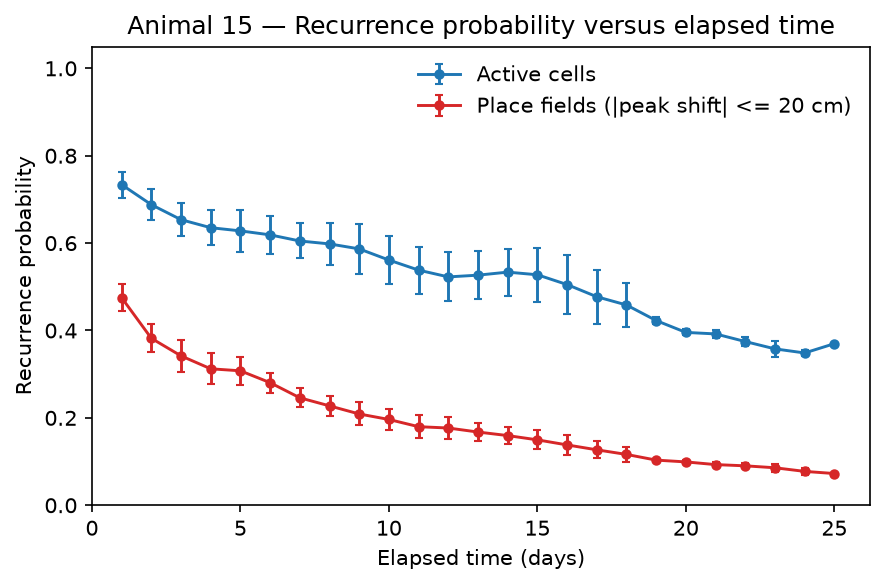

In [5]:
plot_recurrence_probability_vs_lag(report=drift_report, animal_id=ANIMAL)
plt.show()

### 4.3 Population vector correlation vs lag

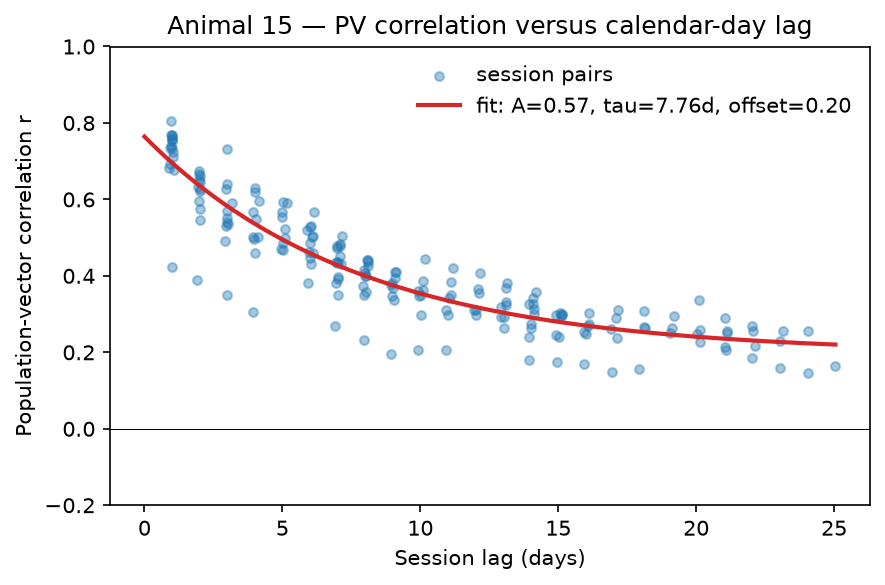

In [6]:
plot_population_vector_correlation_vs_lag(report=drift_report, animal_id=ANIMAL)
plt.show()

### 4.4 Per-cell drift vs bleaching slope

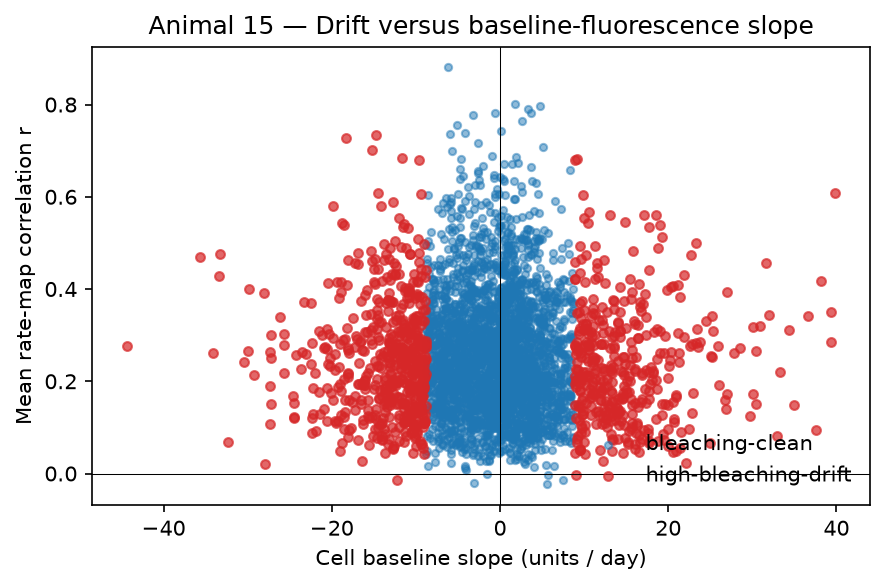

In [7]:
plot_drift_vs_bleaching(report=drift_report, animal_id=ANIMAL)
plt.show()

### 4.5 Sessions-active distribution

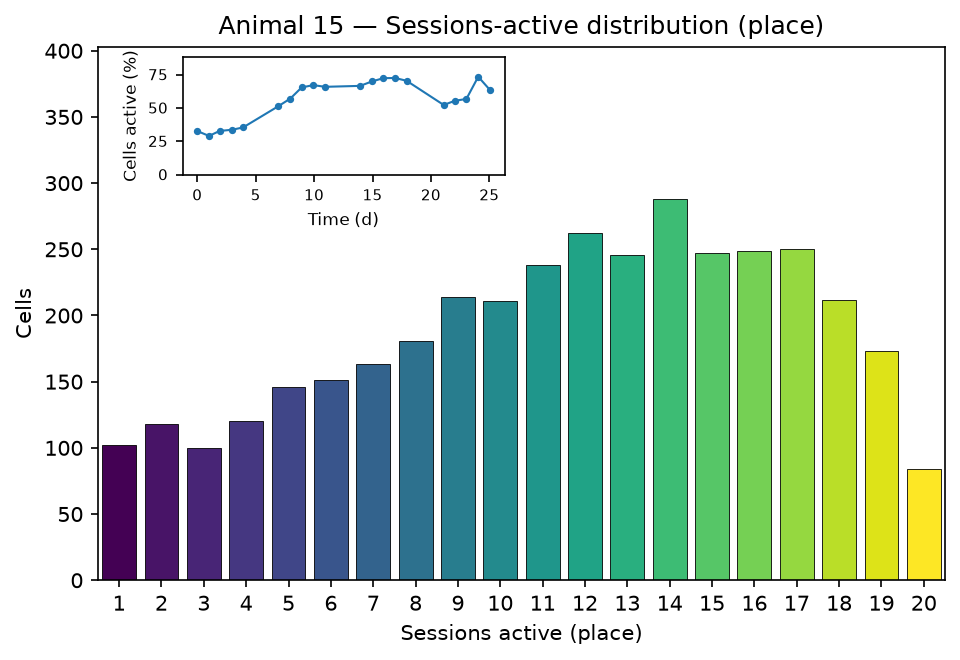

In [8]:
plot_sessions_active_distribution(report=drift_report, animal_id=ANIMAL)
plt.show()

### 4.6 Drift profile categories

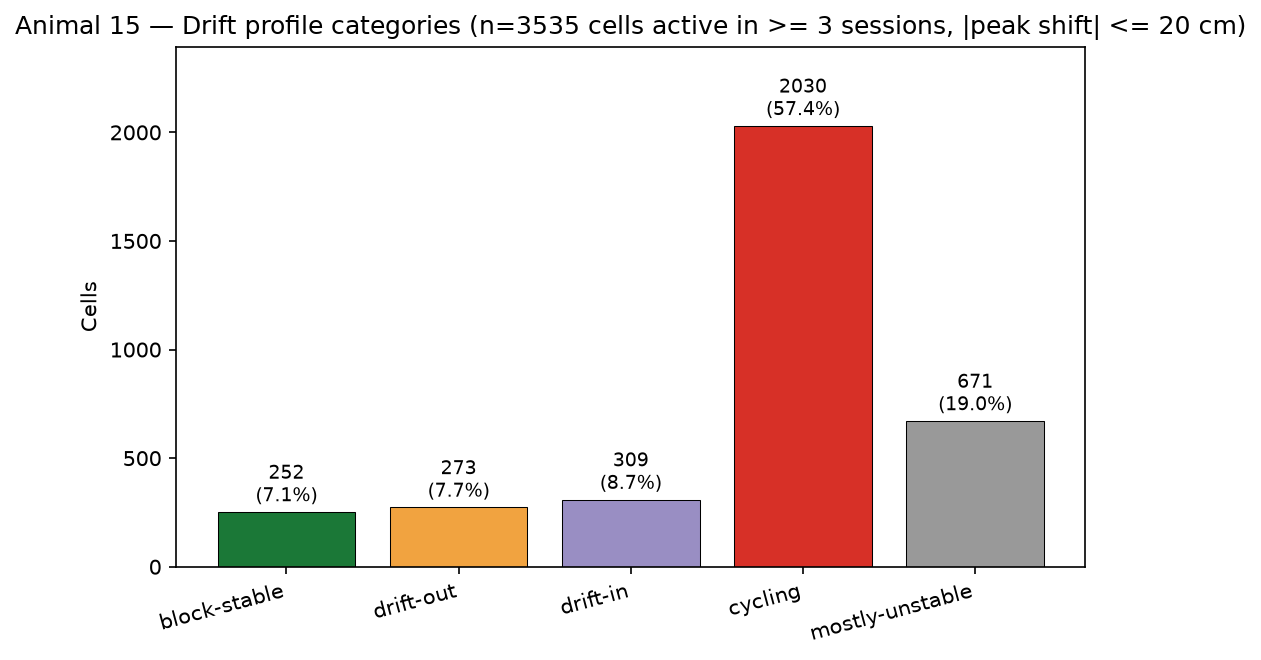

In [9]:
plot_drift_profile_categories(report=drift_report, sessions=sessions, animal_id=ANIMAL)
plt.show()

### 4.7 Reference-day-sorted rate maps

/home/cyberaxolotl/Desktop/GitHubRepos/sollertia-forgery/src/sollertia_forgery/analysis/drift/plotting.py:685: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout(rect=(0, 0, 1, 0.95))


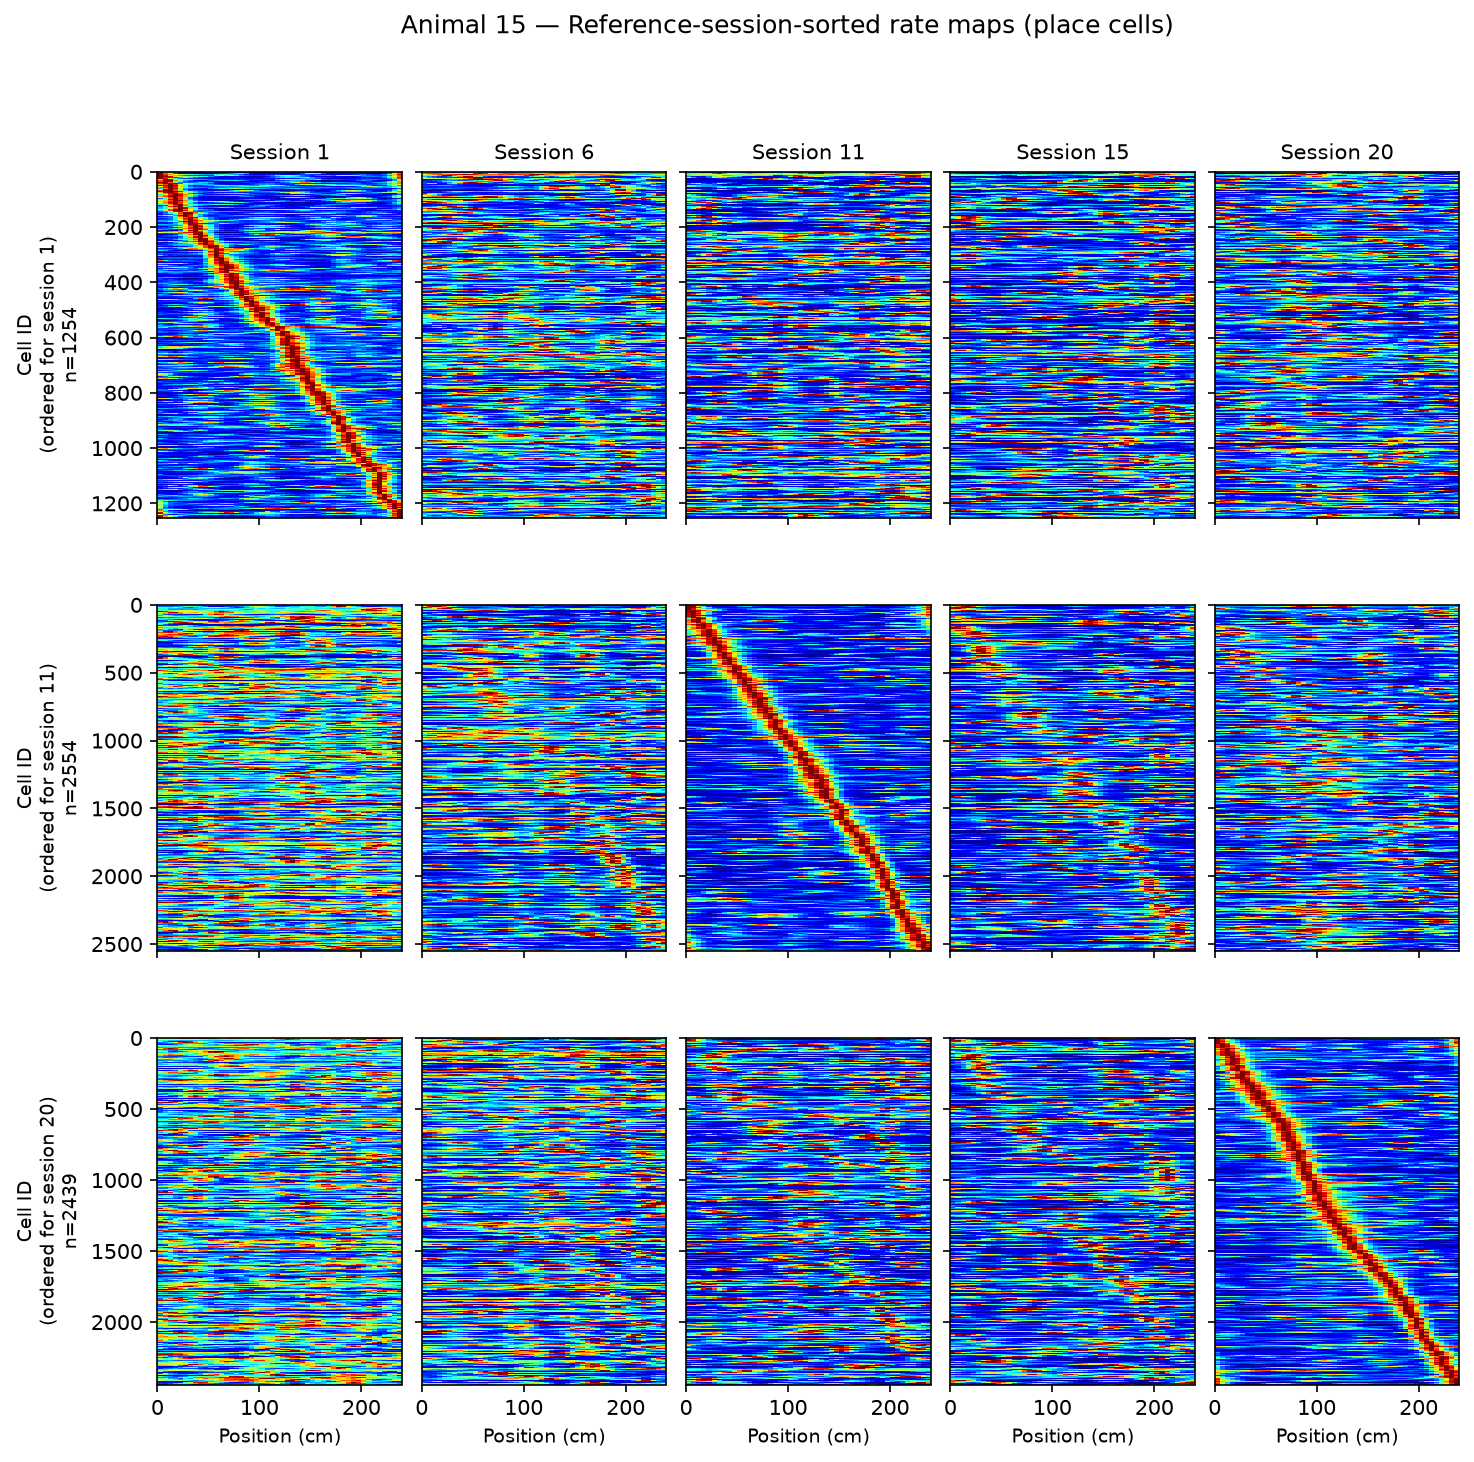

In [10]:
plot_reference_day_sorted_rate_maps(report=drift_report, sessions=sessions, animal_id=ANIMAL)
plt.show()

### 4.8 Recurrence heatmap

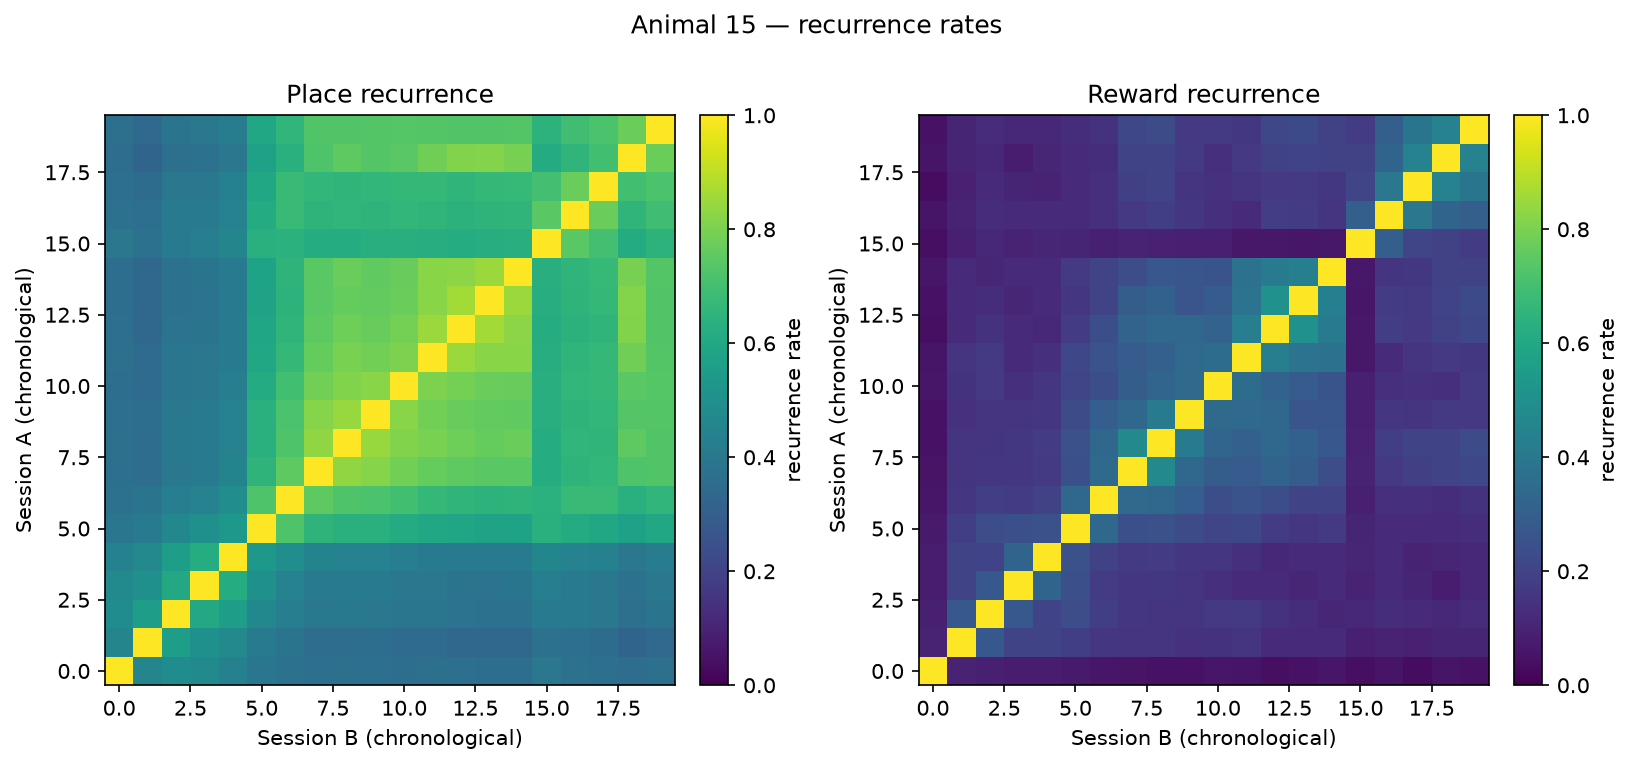

In [12]:
plot_recurrence_heatmap(report=drift_report, animal_id=ANIMAL)
plt.show()